# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [22]:
import pandas as pd

Load our cleaned DataFrames

In [23]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_cl = pd.read_csv(path)

In [24]:
# create copies of original dataframe

orders_df = orders_cl.copy()
orderlines_df = orderlines_cl.copy()
products_df = products_cl.copy()
brands_df = brands_cl.copy()

# Data range of Study

In [25]:
# 1) Change the name in order_id column in orderlines_
orderlines_df = orderlines_df.rename(columns={"id_order": "order_id", "product_quantity": "qty"})

orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])
orderlines_df["date"].max() - orderlines_df["date"].min()

Timedelta('437 days 13:51:17')

# Exclude unwanted orders

In [26]:
# 1. Change the name in order_id column in orderlines_
orderlines_df = orderlines_df.rename(columns={"id_order": "order_id", "product_quantity": "qty"})

# 2. Take only completed orders
orders_df = orders_df.loc[orders_df["state"] == "Completed", :]

# 3. Keep only the "order_id" in orderlines_df that are in orders_df (all = Completed)
orderlines_df = orderlines_df.loc[orderlines_df["order_id"].isin(orders_df["order_id"]), :]

# 4. Keep only the "order_id" in orders_df that are in orderlines_df
orders_df = orders_df.loc[orders_df["order_id"].isin(orderlines_df["order_id"]), :]

# Check
print("Unique order_id:", orders_df["order_id"].nunique())
print("Unique order_id:", orderlines_df["order_id"].nunique())

Unique order_id: 43064
Unique order_id: 43064


# Exclude orders with unknown products


In [27]:
# Identify rows in orderlines_df where SKU is not in products_df
orderlines_sku_notinproducts = orderlines_df[~(orderlines_df["sku"].isin(products_df["sku"]))]

# Extract the unique value of order_id so that orders without SKU in products_df can be deleted
orders_to_be_deleted = orderlines_sku_notinproducts["order_id"].unique()

# Filter orderlines_df to exclude all rows belonging to the corrupted orders
orderlines_df = orderlines_df[~(orderlines_df["order_id"].isin(orders_to_be_deleted))]

# Filter orders_df to exclude the same corrupted orders and keep tables synchronized
orders_df = orders_df[~(orders_df["order_id"].isin(orders_to_be_deleted))]

#Check
orders_df["order_id"].nunique(), orderlines_df["order_id"].nunique()

(41701, 41701)

# Comparison between Total Paid and Actual Cart Value

In [28]:
# 1. Calculate the theoretical total price for each individual order line (quantity * transaction price)
orderlines_df["unit_price_total"] = orderlines_df["unit_price"] * orderlines_df["qty"]

In [29]:
# 2. Group by order_id to compute the total cart value for each order and reset the index to keep it as a DataFrame
grouped_orderlines = orderlines_df.groupby("order_id", as_index = False)["unit_price_total"].sum()

### What is the average difference between `total_paid` and `unit_price_total`?

In [30]:
# 1. Perform a left merge to attach the calculated cart totals to the main orders DataFrame
comparison_df = orders_df.merge(grouped_orderlines, on="order_id", how="left")

# 2. Calculate the net difference (Positive values = shipping fees | Negative values = cart coupons)
comparison_df["price_diff"] = comparison_df["total_paid"] - comparison_df["unit_price_total"]

# 3. Display the initial statistical distribution to detect any major data anomalies
print("--- Price Differences: INITIAL Distribution ---")
print(comparison_df["price_diff"].describe())

# 4. Apply the Interquartile Range (IQR) method to filter out statistical outliers
q25_diff = comparison_df["price_diff"].quantile(0.25)
q75_diff = comparison_df["price_diff"].quantile(0.75)
iqr_diff = q75_diff - q25_diff

# Calculate outlier thresholds
lower_bound_diff = q25_diff - (1.5 * iqr_diff)
upper_bound_diff = q75_diff + (1.5 * iqr_diff)

# Filter the DataFrame to retain only data within the acceptable bounds
comparison_df = comparison_df[
    (comparison_df["price_diff"] >= lower_bound_diff) &
    (comparison_df["price_diff"] <= upper_bound_diff)
]

# 5. Verify the final clean distribution after outlier removal, rounding values to 2 decimal places
print("\n--- Price Differences: FINAL Distribution (Cleaned with IQR) ---")
print(comparison_df["price_diff"].describe().round(2))


--- Price Differences: INITIAL Distribution ---
count    41701.000000
mean         4.474808
std         26.046478
min       -165.000000
25%          0.000000
50%          4.990000
75%          6.990000
max       3984.990000
Name: price_diff, dtype: float64

--- Price Differences: FINAL Distribution (Cleaned with IQR) ---
count    40985.00
mean         3.94
std          2.83
min         -5.00
25%          0.00
50%          4.99
75%          6.99
max         16.97
Name: price_diff, dtype: float64


### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

In [31]:
# Yes, since outliers are not in our dataframe anymore, all costs are aligned with commercial logic.
# The fixed peaks at 4.99€ and 6.99€ rapresent the e-commerce standard shipping rates. Max values of €16.97 is compatible with a very heavy shipping.
# Negative values (until -5.00€) are explained by the use of coupons or discount vouchers applied to the cart during checkout.

### Total Revenue

In [32]:
# 2) Calculate the total revenue summing the total paid for all the order_id in comparison_df

total_revenue = comparison_df["total_paid"].sum().round(2)

total_revenue

np.float64(7978675.6)

# Paid Price vs. List Price Comparison (Discount Analysis)

In [33]:
# 1. Perform a left merge to attach the original list price from products_df to the sales data in orderlines_df
orderlines_products = orderlines_df.merge(products_df, on="sku", how="left")

# 2. Calculate the unit discount in euros for each individual product sold
orderlines_products["discount_euro"] = orderlines_products["price"] - orderlines_products["unit_price"]

# 3. Display the initial statistical distribution to detect price anomalies and extreme discount outliers
print("--- Product Discounts: INITIAL Distribution ---")
print(orderlines_products["discount_euro"].describe())

# 4. Apply the scientific IQR rule to isolate realistic commercial discounts automatically
q25_disc = orderlines_products["discount_euro"].quantile(0.25)
q75_disc = orderlines_products["discount_euro"].quantile(0.75)
iqr_disc = q75_disc - q25_disc

# Calcoliamo le soglie della prof (il limite inferiore e superiore)
lower_bound_disc = q25_disc - (1.5 * iqr_disc)
upper_bound_disc = q75_disc + (1.5 * iqr_disc)

# Create surgical masks based on scientific statistical boundaries
mask1 = orderlines_products["discount_euro"] >= lower_bound_disc
mask2 = orderlines_products["discount_euro"] <= upper_bound_disc

# 5. Apply the combined masks to filter out corrupted records and clean the dataset
orderlines_products = orderlines_products[mask1 & mask2]

# 6. Verify the final clean product discount distribution, rounding metrics to 2 decimal places
print("\n--- Product Discounts: FINAL Distribution (Cleaned with IQR) ---")
print(orderlines_products["discount_euro"].describe().round(2))


--- Product Discounts: INITIAL Distribution ---
count    54324.000000
mean        26.731552
std         46.735906
min       -170.990000
25%          5.550000
50%         15.000000
75%         31.860000
max       1320.000000
Name: discount_euro, dtype: float64

--- Product Discounts: FINAL Distribution (Cleaned with IQR) ---
count    50103.00
mean        18.48
std         17.69
min        -33.64
25%          5.00
50%         14.00
75%         25.03
max         71.29
Name: discount_euro, dtype: float64


### How many products are discounted?

In [34]:
# 1. We need to take all the orders having discounts (discount_euro > 0)

orders_with_discount = orderlines_products.loc[orderlines_products["discount_euro"] > 0]

# 2. We count "name" unique values in these orders (with discounts)

products_with_discount = orders_with_discount["name"].nunique()

# 3. We count the total of unique "name" in the entire dataset (our catalog)

total_products = orderlines_products["name"].nunique()

# 4. We divide the total of unique "name" to find the final percentage

((products_with_discount / total_products) * 100)

95.9374321094938

### What is the discount size in percentage?

In [35]:
# Calculate the discount percentage for each individual product row
discount_percentage = ((orderlines_products["price"] - orderlines_products["unit_price"]) / orderlines_products["price"]) * 100
orderlines_products["discount_percentage"] = discount_percentage

# 1. Calculate the quartiles and Interquartile Range (IQR) directly on the discount percentage column
q25_pct = orderlines_products["discount_percentage"].quantile(0.25)
q75_pct = orderlines_products["discount_percentage"].quantile(0.75)
iqr_pct = q75_pct - q25_pct

# 2. Define the scientific statistical boundaries (Tukey's fences) using the 1.5x IQR rule
lower_bound_pct = q25_pct - (1.5 * iqr_pct)
upper_bound_pct = q75_pct + (1.5 * iqr_pct)

# 3. Apply the surgical masks to filter out unrealistic values and extreme percentage outliers
orderlines_products_clean_pct = orderlines_products[
    (orderlines_products["discount_percentage"] >= lower_bound_pct) &
    (orderlines_products["discount_percentage"] <= upper_bound_pct)
]

# 4. Display the final clean statistical distribution of product discounts rounded to 2 decimal places
orderlines_products_clean_pct["discount_percentage"].describe().round(2)

,discount_percentage
count,47195.00
mean,18.37
std,13.77
min,-21.01
25%,8.00
50%,16.54
75%,25.88
max,58.37


<Axes: title={'center': 'Distribution of Discount Percentages (Cleaned via IQR)'}, ylabel='Frequency'>

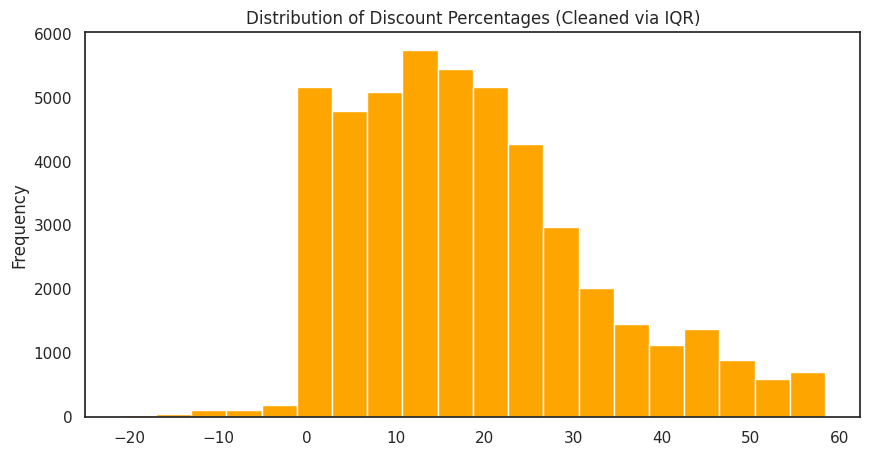

In [36]:
# Calculate the discount percentage for each individual product row
discount_percentage = ((orderlines_products["price"] - orderlines_products["unit_price"]) / orderlines_products["price"]) * 100
orderlines_products["discount_percentage"] = discount_percentage

# Generate a native Pandas histogram to visualize the distribution of discount percentages
orderlines_products_clean_pct["discount_percentage"].plot(
    kind="hist",
    bins=20,                 # Divide the percentage values into 20 logical bars
    color="orange",           # Corporate orange color for visual consistency
    figsize=(10, 5),          # Set an elegant, readable width and height for the plot
    title="Distribution of Discount Percentages (Cleaned via IQR)"
)

# Seasonal Trends (Month-over-Month Evolution)

In [37]:
# 1. Convert "created_date" column to datetime objects to enable time-series operations
comparison_df["created_date"] = pd.to_datetime(comparison_df["created_date"])

# 2. Resample the data by Month-End (ME) to calculate total revenue and order volume
revenue_per_month = (
    comparison_df.resample("ME", on="created_date") # "ME" groups data by month-end intervals
    .agg({
        "total_paid" : "sum",
        "order_id" : "count"
    })
    .reset_index()
)

# 3. Rename columns for better readability and presentation
revenue_per_month = revenue_per_month.rename(columns={
    "created_date": "Month",
    "total_paid": "Total_Revenue",
    "order_id": "Order_Volume"
})

# 4. Display the final aggregated table showing monthly revenue and order trends
revenue_per_month


,Month,Total_Revenue,Order_Volume
0,2017-01-31,620623.31,4597
1,2017-02-28,341848.26,2045
2,2017-03-31,24976.81,163
3,2017-04-30,230994.54,1460
4,2017-05-31,333930.28,1651
5,2017-06-30,292248.33,1329
6,2017-07-31,610519.07,3074
7,2017-08-31,385907.56,2098
8,2017-09-30,395974.90,1880
9,2017-10-31,558111.08,2768


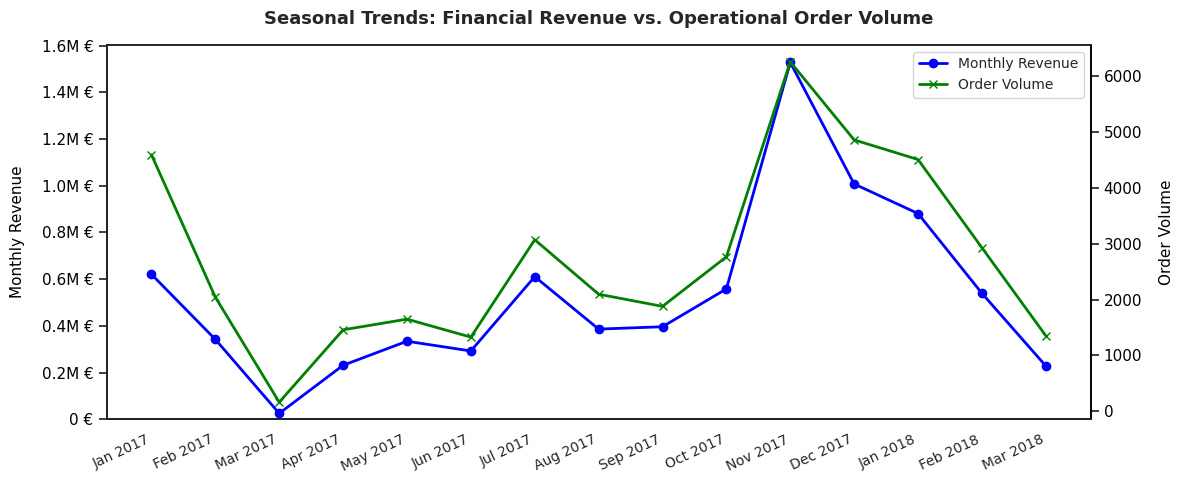

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. EXTRACT DATA AS PURE LISTS (Bypassing Pandas date plotting bugs)
# ==============================================================================
date_formatted = pd.to_datetime(revenue_per_month["Month"])
mesi_completi = date_formatted.dt.strftime("%b %Y").tolist()

# Convert columns into standard numerical lists
valori_fatturato = revenue_per_month["Total_Revenue"].tolist()
valori_volumi = revenue_per_month["Order_Volume"].tolist()
x_indices = list(range(len(revenue_per_month)))

# ==============================================================================
# 2. PLOTTING THE CHART WITH PURE MATPLOTLIB (MAXIMUM VISUAL CONTROL)
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(12, 5))

# BLUE LINE: Monthly Revenue (Left Y-Axis)
line1 = ax1.plot(
    x_indices,
    valori_fatturato,
    color="blue",
    marker="o",
    linewidth=2,
    label="Monthly Revenue"
)

# Left Axis Configuration (Formatted in Millions "M €")
ax1.set_ylabel("Monthly Revenue", color="black", fontsize=11, labelpad=12)
ax1.tick_params(axis="y", labelcolor="black", labelsize=11)
ax1.set_ylim(bottom=0)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M €" if x != 0 else "0 €")
)

# GREEN LINE: Order Volume (Right Y-Axis)
ax2 = ax1.twinx()
line2 = ax2.plot(
    x_indices,
    valori_volumi,
    color="green",
    marker="x",
    linewidth=2,
    label="Order Volume"
)

# Right Axis Configuration
ax2.set_ylabel("Order Volume", color="black", fontsize=11, labelpad=12)
ax2.tick_params(axis="y", labelcolor="black", labelsize=11)
ax2.grid(False) # Disable the double grid overlay

# ==============================================================================
# 3. FORCE X-AXIS LABELS: DISPLAY EVERY SINGLE MONTH
# ==============================================================================
ax1.set_xlabel("")
ax1.set_xticks(x_indices) # Forces Matplotlib to place a tick for every single month
ax1.set_xticklabels(mesi_completi, rotation=25, ha="right", fontsize=10)

# Merge both legends into a single clean box in the upper right corner
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="upper right", frameon=True, prop={'size': 10})

# Chart Title
ax1.set_title("Seasonal Trends: Financial Revenue vs. Operational Order Volume", fontsize=13, fontweight="bold", pad=15)

# Force the chart spines to be sharp and solid black
ax1.spines["bottom"].set_color("black")
ax1.spines["left"].set_color("black")
ax2.spines["right"].set_color("black")

plt.tight_layout()
plt.show()


## Does revenue increase as discounts increase?

In [39]:
# [FIXED WITH REAL COLUMN]: Calculate total revenue using the correct 'qty' column from the database
orderlines_products["unit_price_total"] = orderlines_products["unit_price"] * orderlines_products["qty"]

# 2. Resample the transactional data by Month-End (ME) to calculate monthly metrics
report_discount_revenue = (
    orderlines_products.resample("ME", on="date") # "ME" groups data by month-end intervals
    .agg({
        "discount_percentage": "mean",
        "unit_price_total": "sum"
    })
    .reset_index()
)

# 3. Rename columns for clear reporting and business presentation
report_discount_revenue = report_discount_revenue.rename(columns={
    "date": "Month",
    "discount_percentage": "Avg_Discount_in%",
    "unit_price_total": "Total_Revenue_Month"
})

# 4. Output the final monthly aggregation table for validation
report_discount_revenue


,Month,Avg_Discount_in%,Total_Revenue_Month
0,2017-01-31,23.745291,472702.79
1,2017-02-28,19.334658,252661.21
2,2017-03-31,18.694159,21236.37
3,2017-04-30,18.322997,192848.64
4,2017-05-31,15.582019,252412.80
5,2017-06-30,17.415261,207480.21
6,2017-07-31,25.119014,468145.27
7,2017-08-31,19.668533,300242.24
8,2017-09-30,19.855925,323119.98
9,2017-10-31,21.631985,463215.46


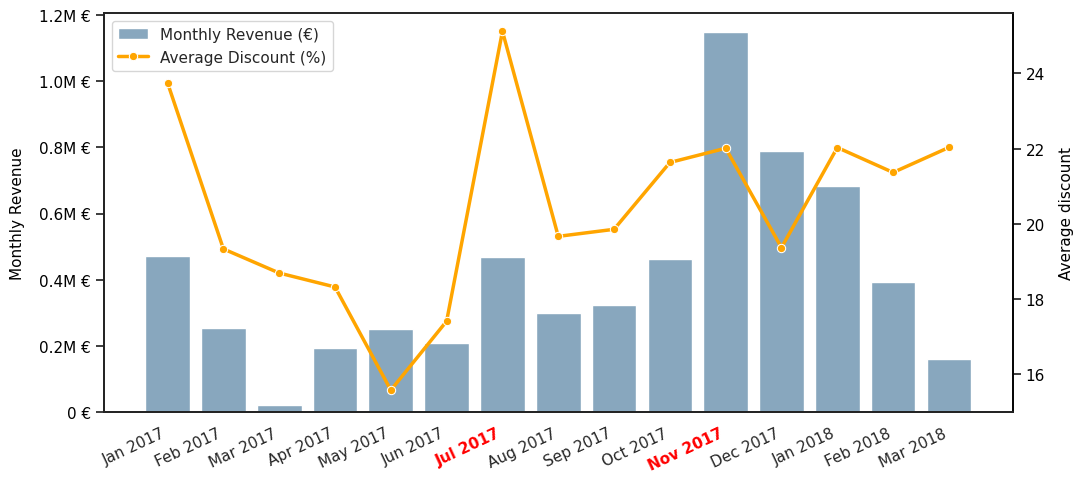

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Set a clean white theme without background grids
sns.set_theme(style="white")

# 2. Initialize the main figure and primary axes
fig, ax1 = plt.subplots(figsize=(11, 5))

# Generate numerical indices to ensure uniform spacing and prevent layout issues
x_indices = list(range(len(report_discount_revenue)))

# 3. Plot the Monthly Revenue as a bar chart on the primary left Y-axis
sns.barplot(
    x=x_indices,
    y=report_discount_revenue["Total_Revenue_Month"],
    color="#7fa9c7",  # Light blue hue
    ax=ax1,
    label="Monthly Revenue (€)"
)

# Configure the primary left Y-axis style and labels
ax1.set_ylabel("Monthly Revenue", color="black", fontsize=11, labelpad=10)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(bottom=0)

# Format primary Y-axis labels to a compact millions format (e.g., "1.5M €")
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M €" if x != 0 else "0 €")
)

# 4. Create a secondary Y-axis and plot the Average Discount line chart
ax2 = ax1.twinx()
sns.lineplot(
    x=x_indices,
    y=report_discount_revenue["Avg_Discount_in%"],
    color="orange",
    marker="o",  # Circular markers for data points
    linewidth=2.5,
    ax=ax2,
    sort=False,
    label="Average Discount (%)"
)

# Configure the secondary right Y-axis style and labels
ax2.set_ylabel("Average discount", color="black", fontsize=11, labelpad=10)
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(bottom=15)  # Set lower bound to emphasize discount peaks
ax2.grid(False)          # Explicitly disable the grid on the secondary axis

# 5. Merge independent labels into a unified legend box in the upper-left corner
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=True)

# 6. Format the X-axis labels to display chronological dates (e.g., "Jan 2017")
date_formatted = pd.to_datetime(report_discount_revenue["Month"])
mesi_completi = date_formatted.dt.strftime("%b %Y").tolist()

ax1.set_xlabel("")
ax1.set_xticks(x_indices)
ax1.set_xticklabels(mesi_completi, rotation=25, ha="right")

# Apply black borders to the plot area for enhanced structural definition
ax1.spines["bottom"].set_color("black")
ax1.spines["left"].set_color("black")
ax2.spines["right"].set_color("black")

# 7. Highlight peak promotional months (July and November) in red and bold font
for tick in ax1.get_xticklabels():
    nome_mese = tick.get_text()
    if "Jul" in nome_mese or "Nov" in nome_mese:
        tick.set_color("red")
        tick.set_fontweight("bold")
        tick.set_fontsize(11)

plt.tight_layout()
plt.show()
